In [1]:
# Import standard libraries
import sys

sys.path.append("..")

import phcpy  # Homotopy continuation package
from phcpy.dimension import get_core_count # For getting number of CPU cores
from phcpy.solver import solve # For solving polynomial systems
from phcpy.solutions import filter_real # For filtering real solutions

import sympy as sp # For symbolic mathematics
from sympy.parsing.sympy_parser import parse_expr

import matplotlib.pyplot as plt # For plotting
import plotly.graph_objects as go

# Import our modules
from src.model import *
from src.nnexpansion import *
from src.utils import *

from src.edop import *

PHCv2.4.90 released 2024-03-20 works!


In [2]:
model = PolynomialNetwork(
    input_dim=2,
    output_dim=2,  # Binary classification with 2 outputs
    hidden_dims=[8, 6],
    polynomial_degree=3,
)
model.load_state_dict(torch.load("./saved_models/polynomial_nn_model.pth"))

<All keys matched successfully>

In [3]:
# Monomial Expansion
polys, _, _ = polynomial_nn_expansion(model)
poly_decision = polys[1] - polys[0]

Input symbols: (x0, x1)
Layer 0 weight: (8, 2)
Layer 0 bias: (8, 1)
Layer 0 activation: (4,)
Layer 1 weight: (6, 8)
Layer 1 bias: (6, 1)
Layer 1 activation: (4,)
Layer 2 weight: (2, 6)
Layer 2 bias: (2, 1)
Layer 2 activation: None
Polynomial expansion took 0.8070 seconds.


In [4]:
# Create meshgrid for the region [-30, 10] x [-20, 20]
x_range = np.linspace(-30, 10, 20)  # Adjust resolution as needed
y_range = np.linspace(-20, 20, 20)  # Adjust resolution as needed
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# Initialize matrix to store number of real critical points
num_critical_points = np.zeros_like(X_mesh)

# Iterate over each grid point
print(f"Evaluating {X_mesh.shape[0]} x {X_mesh.shape[1]} = {X_mesh.size} grid points...")
for i in trange(X_mesh.shape[0]):
    for j in range(X_mesh.shape[1]):
        x_center = np.array([X_mesh[i, j], Y_mesh[i, j]])
        print(f"\nGrid point ({i}, {j}): x_center = {x_center}")
        
        # Get critical points without plotting
        _, _, real_sols = get_critical_points(x_center, poly_decision, model, plot=False)
        
        # Store the number of real critical points
        num_critical_points[i, j] = len(real_sols)
        print(f"Number of real critical points: {len(real_sols)}")

print(f"\nCompleted evaluation of all grid points.")
print(f"Number of critical points range: [{num_critical_points.min()}, {num_critical_points.max()}]")

Evaluating 20 x 20 = 400 grid points...


  0%|          | 0/20 [00:00<?, ?it/s]


Grid point (0, 0): x_center = [-30. -20.]
Using 31 CPU cores for homotopy continuation.
Solved in 0.08 seconds.
Found 5 real solutions out of 81 complex solutions.
Removing duplicates, 5 unique real solutions remain.
Closest critical point: [-31.71620685   1.26609914]
Distance to closest critical point (gamma): 21.33523701939048
Number of real critical points: 5

Grid point (0, 1): x_center = [-27.89473684 -20.        ]
Using 31 CPU cores for homotopy continuation.
Solved in 0.10 seconds.
Found 5 real solutions out of 81 complex solutions.
Removing duplicates, 5 unique real solutions remain.
Closest critical point: [-29.95600555   1.42049401]
Distance to closest critical point (gamma): 21.519442195639304
Number of real critical points: 5

Grid point (0, 2): x_center = [-25.78947368 -20.        ]
Using 31 CPU cores for homotopy continuation.
Solved in 0.11 seconds.
Found 5 real solutions out of 144 complex solutions.
Removing duplicates, 5 unique real solutions remain.
Closest critical

In [30]:
fig = go.Figure()
fig.add_trace(
    go.Contour(
        x=x_range,
        y=y_range,
        z=num_critical_points,
        contours=dict(
            start=num_critical_points.min(),
            end=num_critical_points.max(),
            size=1,
        ),
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="Number of Critical Points"),
        name="Critical Points Count",
        showlegend=True,
    )
)
fig.add_trace(
    go.Contour(
        x=x_range,
        y=y_range,
        z=Z,
        contours=dict(start=0, end=0, coloring="lines"),
        colorscale=[[0, "blue"], [1, "blue"]],
        showscale=False,
        line=dict(width=3),
        name="Decision Boundary",
        showlegend=True,
    )
)
fig.update_layout(
    margin=dict(l=10, r=10, t=10, b=10),
            legend=dict(
                x=0.95,
                y=0.95,
                xanchor="right",
                yanchor="top",
                bgcolor="rgba(255,255,255,0.6)",  # optional: semi-transparent background
                bordercolor="black",
                borderwidth=1,
            ),
            xaxis=dict(showgrid=False, zeroline=False),
            yaxis=dict(showgrid=False, zeroline=False),
            xaxis_title="x0",
            yaxis_title="x1",
            width=800,
            height=800,
)


fig.show()



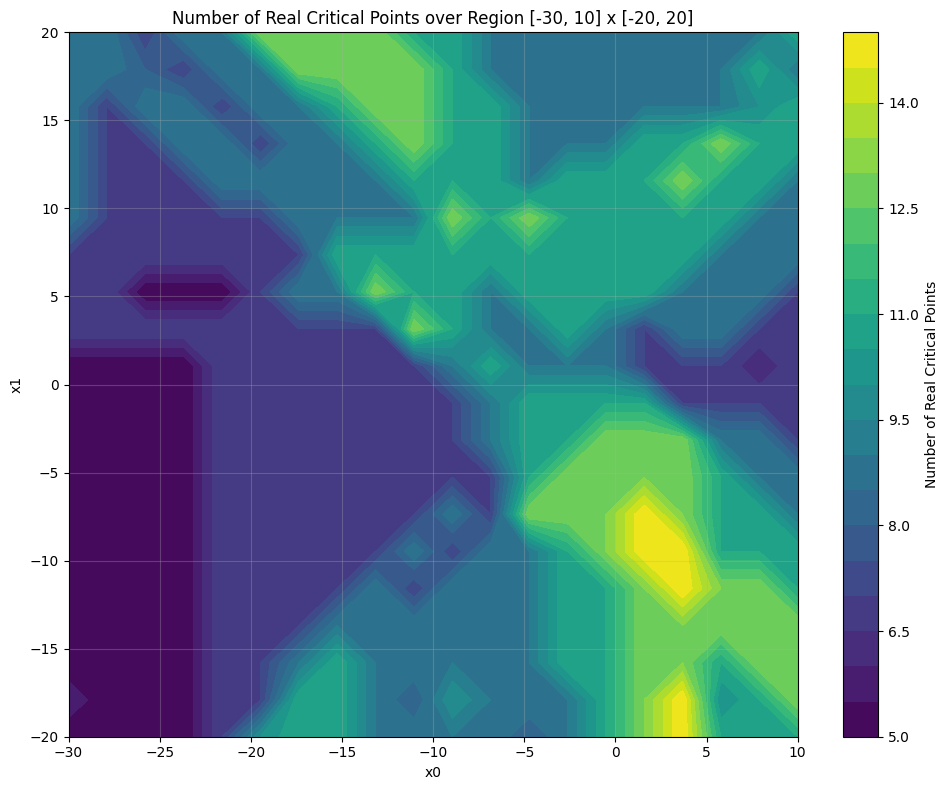


Saved critical points matrix to 'critical_points_matrix.npy'
Matrix shape: (20, 20)
Saved complete data (meshgrid + matrix) to 'critical_points_data.npz'


In [5]:
# Visualize the number of critical points as a heatmap
plt.figure(figsize=(10, 8))
plt.contourf(X_mesh, Y_mesh, num_critical_points, levels=20, cmap='viridis')
plt.colorbar(label='Number of Real Critical Points')
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('Number of Real Critical Points over Region [-30, 10] x [-20, 20]')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/critical_points_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Save the matrix to a file
np.save('critical_points_matrix.npy', num_critical_points)
print(f"\nSaved critical points matrix to 'critical_points_matrix.npy'")
print(f"Matrix shape: {num_critical_points.shape}")

# Also save the meshgrid coordinates for reference
np.savez('critical_points_data.npz', 
         X_mesh=X_mesh, 
         Y_mesh=Y_mesh, 
         num_critical_points=num_critical_points,
         x_range=x_range,
         y_range=y_range)
print(f"Saved complete data (meshgrid + matrix) to 'critical_points_data.npz'")